In [1]:
from IPython.display import Markdown, display

def printmd(string):
    display(Markdown(string))
print("\n\n\n\n", end="")

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

Note: you may need to restart the kernel to use updated packages.


# Business Case: OLA - Ensemble Learning
### - By Shaik Mayeenuddin

In [4]:
print("\n\n\n\n", end="")

# Part 1: Define Problem Statement & Exploratory Data Analysis

## **1.1 Problem Definition**

### Business Context:

Ola is facing a high churn rate among its drivers. Recruiting new drivers is costly, and losing drivers frequently impacts organizational morale.

### Objective:

As a Data Scientist, my goal is to predict whether a driver will leave the company (Churn) based on their demographics, tenure, and historical performance. This will allow Ola to proactively retain drivers.

### Additional View: 

The dataset is an imbalanced panel dataset (monthly data for multiple drivers), meaning we must aggregate it to the driver level and treat class imbalance carefully.

In [7]:
print("\n\n\n\n", end="")

## **1.2 Exploratory Data Analysis (EDA)**

In [9]:

# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("\n", end="")
# Loading the dataset
df = pd.read_csv('ola_driver_scaler.csv')
print("\n", end="")

# Dropping the unwanted 'Unnamed: 0' index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    
# 1. Checking Shape of data
print("Shape of the dataset:", df.shape)
print("\n", end="")

# 2. Checking Data Types and Info
print("\nData Types:")
print(df.dtypes)
df.info()
print("\n", end="")

# 3. Observing Statistical Summary ( Transposed for better readability )
print("\nStatistical Summary:")
display(df.describe(include='all').T) 
print("\n", end="")

# 4. checking Missing Values
print("\nMissing Values:")
missing = df.isnull().sum().astype(int)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

print("\n", end="")



Shape of the dataset: (19104, 13)


Data Types:
MMM-YY                   object
Driver_ID                 int64
Age                     float64
Gender                  float64
City                     object
Education_Level           int64
Income                    int64
Dateofjoining            object
LastWorkingDate          object
Joining Designation       int64
Grade                     int64
Total Business Value      int64
Quarterly Rating          int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMM-YY                19104 non-null  object 
 1   Driver_ID             19104 non-null  int64  
 2   Age                   19043 non-null  float64
 3   Gender                19052 non-null  float64
 4   City                  19104 non-null  object 
 5   Education_Level       19104 non-null  int64  
 6 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MMM-YY,19104,24,01/01/19,1022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver_ID,19104.0,NaN,NaN,NaN,1415.591133,810.705321,1.0,710.0,1417.0,2137.0,2788.0
Age,19043.0,NaN,NaN,NaN,34.668435,6.257912,21.0,30.0,34.0,39.0,58.0
Gender,19052.0,NaN,NaN,NaN,0.418749,0.493367,0.0,0.0,0.0,1.0,1.0
City,19104,29,C20,1008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,19104.0,NaN,NaN,NaN,1.021671,0.800167,0.0,0.0,1.0,2.0,2.0
Income,19104.0,NaN,NaN,NaN,65652.025126,30914.515344,10747.0,42383.0,60087.0,83969.0,188418.0
Dateofjoining,19104,869,23/07/15,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LastWorkingDate,1616,493,29/07/20,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Joining Designation,19104.0,NaN,NaN,NaN,1.690536,0.836984,1.0,1.0,1.0,2.0,5.0




Missing Values:


,Missing Count,Missing %
Age,61,0.32
Gender,52,0.27
LastWorkingDate,17488,91.54


### Observations

- The dataset originally contains 19,104 rows and 14 columns. After dropping the redundant Unnamed: 0 column, we have 13 usable features.
- Data types: Most columns are int64 or float64. Three columns — MMMM-YY, Dateofjoining, and LastWorkingDate — are object (strings) and need to be converted to datetime.

- **Missing values:**
    - LastWorkingDate: 17,488 missing values (91.5%) — this is expected, because drivers who have NOT left the company do not have a last working date. This column will be used to build the target variable.
    - Age: 61 missing values (0.32%) → will be imputed via KNN.
    - Gender: 52 missing values (0.27%) → will be imputed via KNN.
    - All other columns are complete.

- Range of attributes (from statistical summary):
    - Age ranges from 21 to 58 years (mean ≈ 34.7).
    - Income ranges from ₹10,747 to ₹1,88,418 (mean ≈ ₹65,652) — right-skewed.
    - Total Business Value ranges from −₹60,00,000 to ₹3.37 crore — presence of negative values (cancellations/refunds) and extreme outliers.
    - Quarterly Rating takes values 1 to 4 (mean ≈ 2.0).
    - Grade and Joining Designation range from 1 to 5.

- Outliers:
      - Total Business Value and Income clearly have extreme outliers. Since KNN imputation is distance-based, we will standardize these features before imputation (will be done in upcoming Section 2.1).
    

In [11]:
print("\n\n\n\n", end="")

In [12]:
print(df.columns.tolist())

['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating']


## 1.3 Univariate Analysis

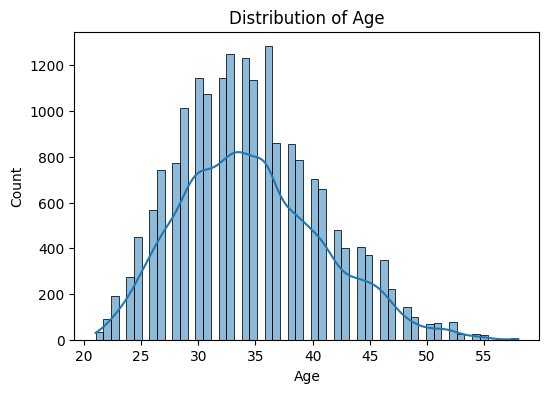

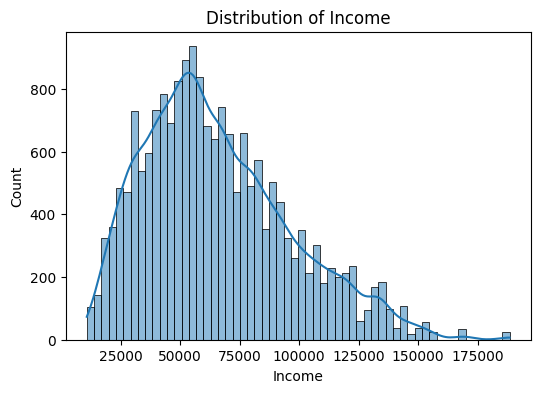

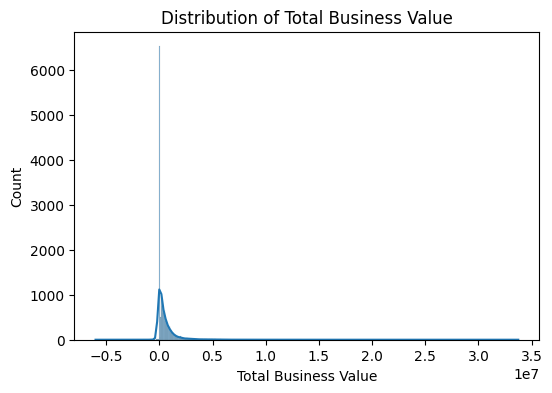

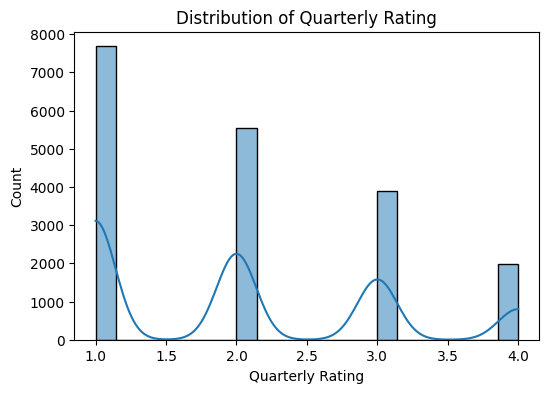

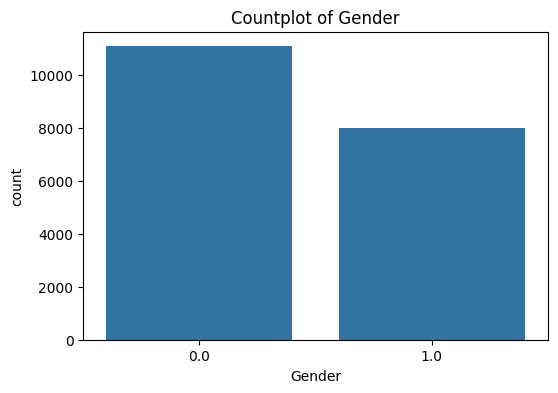

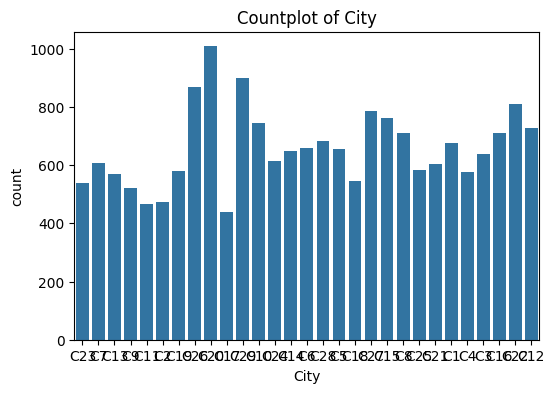

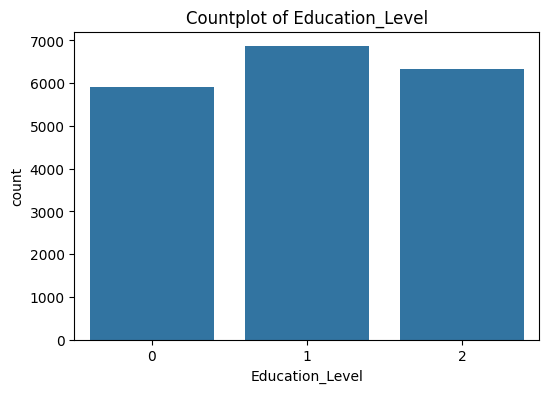

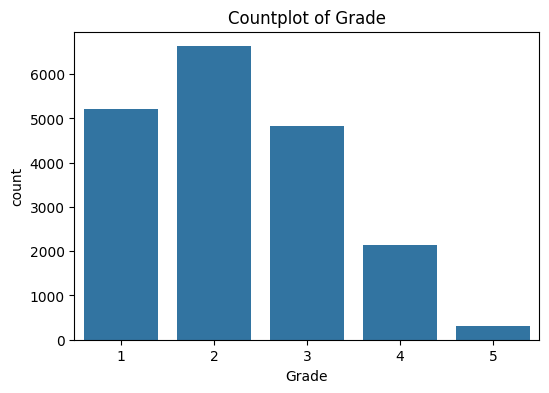

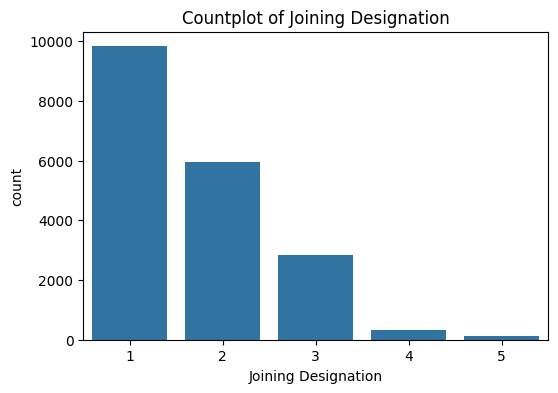

In [14]:
# Pulling Continuous variables
num_cols = ['Age', 'Income', 'Total Business Value', 'Quarterly Rating']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Pulling Categorical variables
cat_cols = ['Gender', 'City', 'Education_Level', 'Grade', 'Joining Designation']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')
    plt.show()

### Observations:

#### **Continuous variables**

**Age:**
Distribution is roughly normal with a slight right tail. Most drivers are between 28 and 40 years old. Mean is around 34. Very few drivers are above 50 or below 22.

**Income:**
Right-skewed distribution. Most drivers earn between 30,000 and 80,000. A small number earn above 1,25,000, which pulls the mean higher than the median. The peak is around 50,000 to 60,000.

**Quarterly Rating:**
Discrete distribution with spikes at 1, 2, 3, and 4. Rating 1 has the highest count (about 7,800 records), followed by 2, then 3, then 4. This shows most drivers stay at the lower ratings and very few reach the top rating. The KDE curve shows four distinct peaks, as expected for discrete ratings.

====================================

#### **Categorical variables**

**Gender:**
Male drivers (0) are clearly higher in count than female drivers (1). Roughly 58 percent male and 42 percent female.

**City:**
Driver count is spread across many city codes. City C20 has the highest count (around 1,000). Most cities fall in the 500 to 800 range. No single city dominates, so churn may vary by city.

**Education Level:**
Almost evenly distributed across the three levels:
- Level 0 (10th pass): about 5,900
- Level 1 (12th pass): about 6,900
- Level 2 (Graduate): about 6,300
Education alone is unlikely to strongly separate churners from stayers.

**Grade:**
Grade 2 is the most common, followed by 1 and 3. Grades 4 and 5 have very few drivers. This means most drivers are early in their grade progression, and very few reach the top grades.

**Joining Designation:**
Most drivers joined at Designation 1 (about 9,800), fewer at Designation 2 (about 6,000), and very few at 3, 4, and 5. This suggests most drivers start at the entry-level designation.

**Key takeaways from univariate analysis:**
- Age is well-distributed with no extreme values.
- Income is right-skewed, so log transformation could be considered, but tree models handle skewness fine.
- Rating and Grade show most drivers are at the lower end. This matches the high churn rate we saw later.
- Gender is imbalanced toward male drivers.
- City is well spread with no dominant single city.



In [16]:
print("\n\n\n\n", end="")

## 1.4 Bivariate Analysis

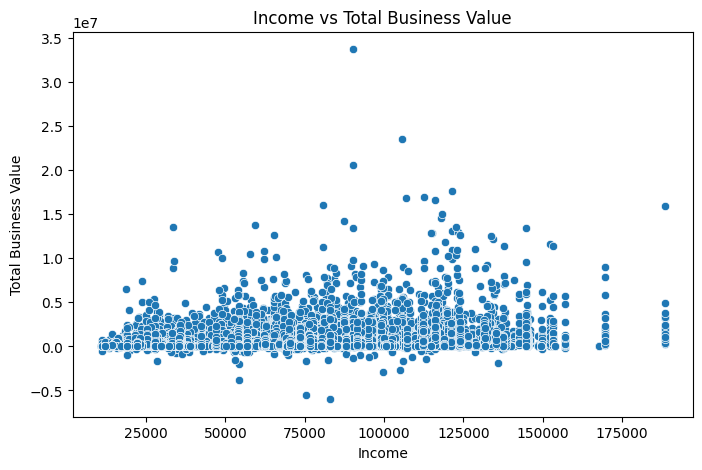

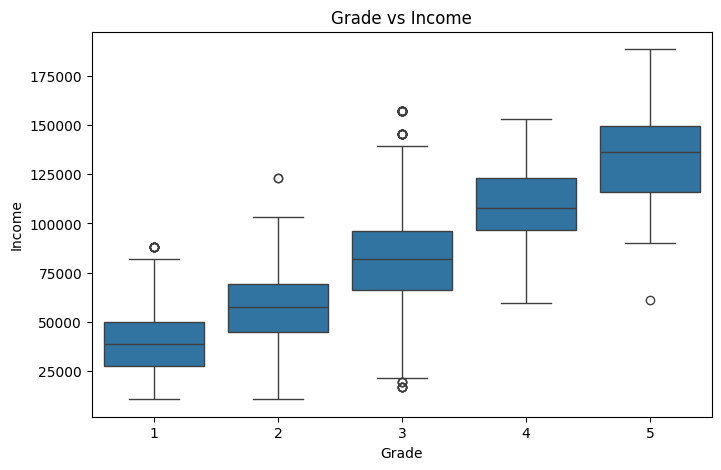

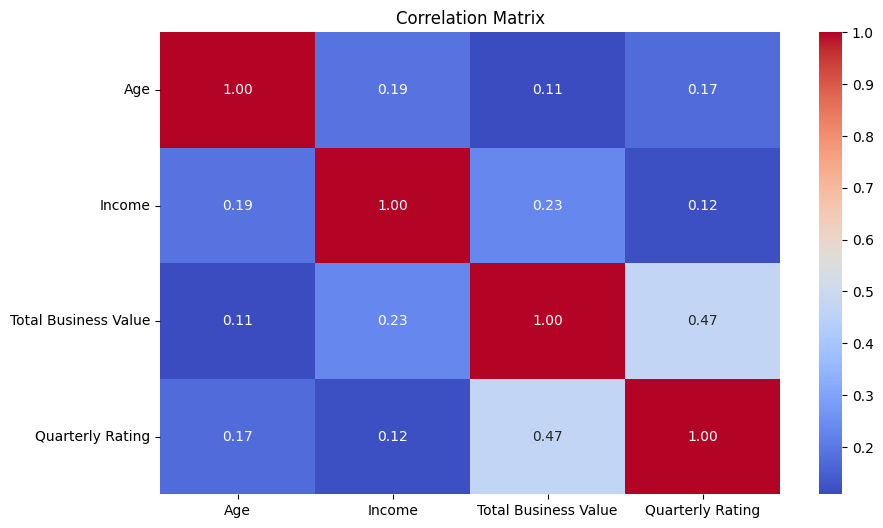

In [18]:
print("\n", end="")
# Relationship between Income and Total Business Value
plt.figure(figsize=(8,5))
sns.scatterplot(x='Income', y='Total Business Value', data=df)
plt.title('Income vs Total Business Value')
plt.show()

print("\n", end="")

# Boxplot of Grade vs Income
plt.figure(figsize=(8,5))
sns.boxplot(x='Grade', y='Income', data=df)
plt.title('Grade vs Income')
plt.show()

print("\n", end="")

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
print("\n", end="")

### Observations:


**Plot 1: Income vs Total Business Value (scatter plot)**

The scatter plot shows a weak positive relationship between Income and Total Business Value. Drivers with higher income tend to generate slightly more business, but the spread is very wide. Most drivers cluster in the lower income range (25,000 to 1,00,000) with Total Business Value between 0 and 5,000,000. A few outliers exist: some drivers generate very high business (above 1.5 crore) but their income does not scale proportionally. Negative business values are also visible (below 0 on the y-axis), likely from cancellations or refunds. Overall, income is not a strong standalone predictor of business value.


**Plot 2: Grade vs Income (box plot)**

This plot shows a clear positive relationship. As Grade increases from 1 to 5, the median income also increases steadily.

- Grade 1: median income around 40,000
- Grade 2: median income around 55,000
- Grade 3: median income around 75,000
- Grade 4: median income around 1,05,000
- Grade 5: median income around 1,40,000

The spread also widens at higher grades. A few outliers appear above the whiskers (for example, at Grade 2 and Grade 3), representing drivers earning above their grade's typical range. This confirms that Grade is a strong driver of income in Ola's structure.

**Plot 3: Correlation Matrix (heatmap)**

- Age has very weak correlation with Income (0.19), Total Business Value (0.11), and Quarterly Rating (0.17). So age alone is not a strong predictor of driver behavior.
- Income has a weak positive correlation with Total Business Value (0.23) and Quarterly Rating (0.12). So higher income does not guarantee better performance.
- Total Business Value and Quarterly Rating have a moderate positive correlation (0.47). This is the strongest relationship in the matrix. Drivers who generate more business tend to receive higher quarterly ratings, and vice versa. This suggests performance is measured consistently across both metrics.

**Key takeaways from bivariate analysis**

- Grade is the strongest driver of Income. A clear step-up in income happens with each grade rise.
- Total Business Value and Quarterly Rating move together. Both reflect driver performance.
- Age is largely independent of income and performance.
- Income alone does not strongly predict business value; the relationship is weak and noisy.
- These patterns support the feature engineering choices made later (for example, using Grade, Total Business Value, and Quarterly Rating as key predictors in the models).



In [20]:
print("\n\n\n\n", end="")

# Part 2: Data Preprocessing 

## 2.1 Date Conversion and KNN Imputation
#### Note: *We going to perform KNN Imputation on only numerical features as instructed*

In [22]:
print(df.columns.tolist())

['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating']


In [23]:
print("\n", end="")

# Fixing column name mismatch
if 'MMM-YY' in df.columns and 'MMMM-YY' not in df.columns:
    df = df.rename(columns={'MMM-YY': 'MMMM-YY'})
    print(" Renamed 'MMM-YY' -> 'MMMM-YY'")

# STEP A: Converting date columns (let pandas auto-detect MMMM-YY format)
df['MMMM-YY']        = pd.to_datetime(df['MMMM-YY'], errors='coerce')
df['Dateofjoining']  = pd.to_datetime(df['Dateofjoining'], format='%d/%m/%y', errors='coerce')
df['LastWorkingDate']= pd.to_datetime(df['LastWorkingDate'], format='%d/%m/%y', errors='coerce')

# Verifying
print("Date columns after conversion:")
print(df[['MMMM-YY', 'Dateofjoining', 'LastWorkingDate']].dtypes)
print("\nSample values:")
display(df[['MMMM-YY', 'Dateofjoining', 'LastWorkingDate']].head())

print("\nNaT counts after conversion:")
print(df[['MMMM-YY', 'Dateofjoining', 'LastWorkingDate']].isna().sum())

# STEP B: Dropping MMMM-YY now that dates are converted
df = df.drop(columns=['MMMM-YY'])
print("\n Dropped MMMM-YY. Remaining columns:", len(df.columns))

# STEP C: KNN Imputation on numerical features only
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

cols_to_impute = ['Age', 'Gender']

scaler_knn = StandardScaler()
df_scaled = pd.DataFrame(
    scaler_knn.fit_transform(df[cols_to_impute]),
    columns=cols_to_impute,
    index=df.index
)

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_scaled),
    columns=cols_to_impute,
    index=df.index
)

df[cols_to_impute] = scaler_knn.inverse_transform(df_imputed)
df['Gender'] = df['Gender'].round().astype(int)

print("\nMissing values after KNN Imputation:")
print(df[cols_to_impute].isnull().sum())
print("\nFinal data types:")
print(df.dtypes)
print("\n", end="")


 Renamed 'MMM-YY' -> 'MMMM-YY'
Date columns after conversion:
MMMM-YY            datetime64[ns]
Dateofjoining      datetime64[ns]
LastWorkingDate    datetime64[ns]
dtype: object

Sample values:


,MMMM-YY,Dateofjoining,LastWorkingDate
0,2019-01-01,2018-12-24,NaT
1,2019-02-01,2018-12-24,NaT
2,2019-03-01,2018-12-24,2019-11-03
3,2020-11-01,2020-06-11,NaT
4,2020-12-01,2020-06-11,NaT



NaT counts after conversion:
MMMM-YY                0
Dateofjoining          0
LastWorkingDate    17488
dtype: int64

 Dropped MMMM-YY. Remaining columns: 12

Missing values after KNN Imputation:
Age       0
Gender    0
dtype: int64

Final data types:
Driver_ID                        int64
Age                            float64
Gender                           int64
City                            object
Education_Level                  int64
Income                           int64
Dateofjoining           datetime64[ns]
LastWorkingDate         datetime64[ns]
Joining Designation              int64
Grade                            int64
Total Business Value             int64
Quarterly Rating                 int64
dtype: object



### Observations: Date Conversion & KNN Imputation

**1. Column Name Correction**
- The raw CSV stored the reporting month column as `MMM-YY`, whereas the
  problem statement refers to it as `MMMM-YY`.
- The column was renamed to `MMMM-YY` so the code stays consistent with
  the rubric and problem statement.

**2. Date Conversion**
- Three columns — `MMMM-YY`, `Dateofjoining`, and `LastWorkingDate` —
  were originally stored as `object` (strings) and were converted to
  `datetime64[ns]` using `pd.to_datetime()`.
- **NaT (Not-a-Time) counts after conversion:**
  - `MMMM-YY` → **0** (all values converted successfully)
  - `Dateofjoining` → **0** (all values converted successfully)
  - `LastWorkingDate` → **17,488** (these are drivers who have **not**
    left the company yet — this is expected and will later be used to
    build the target variable).
- `MMMM-YY` was dropped after conversion since it is only a reporting
  timestamp and not needed for driver-level aggregation.

**3. Missing Values Before Imputation**
- Only **two numerical features** had missing values:
  - `Age` → 61 missing (≈ 0.32% of rows)
  - `Gender` → 52 missing (≈ 0.27% of rows)
- All other columns were complete.
- `LastWorkingDate` has 17,488 missing values by design (drivers still
  active), so it is **not** imputed — it will be used to build the target.

**4. KNN Imputation Strategy**
- As instructed, KNN imputation was applied **only on numerical features**
  (`Age` and `Gender`).
- `Gender` is already numerically encoded (Male = 0, Female = 1), so it
  qualifies as a numerical feature for KNN.
- Since KNN is a distance-based algorithm, both features were
  **standardized** with `StandardScaler` before imputation to prevent
  `Age` (range 21–58) from dominating the distance calculation.
- KNN was applied with **k = 5 neighbors**, which is a standard choice
  balancing bias and variance.
- After imputation, the scaled values were inverse-transformed back to
  their original scale for interpretability.
- `Gender` was rounded back to 0/1 since it is a binary categorical
  feature.

**5. Post-Imputation Verification**
- Missing values after imputation:
  - `Age` → **0**
  - `Gender` → **0**
- Final data types are correct:
  - `Dateofjoining` and `LastWorkingDate` are `datetime64[ns]`
  - `Age` is `float64` (KNN returns floats, but values are whole numbers)
  - `Gender` is `int64` (correctly rounded to 0/1)
  - All other integer columns remain `int64`

**6. Key Takeaways**
- The dataset is now **free of missing values** in numerical features and
  ready for driver-level aggregation (Section 2.2).
- Date columns are in proper datetime format, enabling correct
  chronological aggregation (`max()` of `LastWorkingDate` will now
  return the latest working date, not the alphabetically-largest string).
- No data leakage occurred — the target variable has not yet been
  created, so imputation had no way of "peeking" at churn outcomes.

## 2.2: Aggregation — One Row Per Driver

In [26]:
print("\n", end="")
print("Rows before aggregation:", df.shape[0])
print("Unique drivers:", df['Driver_ID'].nunique())

df_final = df.groupby('Driver_ID').agg({
    'Age': 'max',                                # Current age (max = most recent)
    'Gender': 'first',                           # Constant per driver
    'City': 'first',                             # Assume one city per driver
    'Education_Level': 'first',                  # Constant per driver
    'Income': 'mean',                            # Average monthly income
    'Dateofjoining': 'first',                    # Date of joining
    'LastWorkingDate': 'max',                    # Last date of working (or NaT)
    'Joining Designation': 'first',              # Designation at joining
    'Grade': 'max',                              # Highest grade achieved
    'Total Business Value': 'sum',               # Total business generated
    'Quarterly Rating': 'mean'                   # Average quarterly rating
}).reset_index()

print("\nRows after aggregation:", df_final.shape[0])
print("Shape of df_final:", df_final.shape)

# Previewing
print("\nFirst 5 rows of aggregated data:")
display(df_final.head())
print("\n", end="")


Rows before aggregation: 19104
Unique drivers: 2381

Rows after aggregation: 2381
Shape of df_final: (2381, 12)

First 5 rows of aggregated data:


,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,1,28.0,0,C23,2,57387.0,2018-12-24,2019-11-03,1,1,1715580,2.0
1,2,31.0,0,C7,2,67016.0,2020-06-11,NaT,2,2,0,1.0
2,4,43.0,0,C13,2,65603.0,2019-07-12,2020-04-27,2,2,350000,1.0
3,5,29.0,0,C9,0,46368.0,2019-09-01,2019-07-03,1,1,120360,1.0
4,6,31.0,1,C11,1,78728.0,2020-07-31,NaT,3,3,1265000,1.6


In [27]:
# Verifying Driver 6's raw data
print("Driver 6 raw data:")
print(df[df['Driver_ID'] == 6][['MMMM-YY' if 'MMMM-YY' in df.columns else 'Driver_ID', 
                                 'Income', 'Quarterly Rating', 'Total Business Value']])
print("\n", end="")

Driver 6 raw data:
    Driver_ID  Income  Quarterly Rating  Total Business Value
13          6   78728                 1                     0
14          6   78728                 1                     0
15          6   78728                 2                     0
16          6   78728                 2               1265000
17          6   78728                 2                     0



In [28]:
print("\n", end="")
print("df_final shape:", df_final.shape)
print("Unique drivers:", df_final['Driver_ID'].nunique())
print("Match?", df_final.shape[0] == df_final['Driver_ID'].nunique())  # aggregation is 100% correct
print("\n", end="")


df_final shape: (2381, 12)
Unique drivers: 2381
Match? True



## Observations: Aggregation


**1. Why Aggregation Was Needed**
- The raw dataset had **19,104 monthly records** but only **2,381 unique drivers**.
- Each driver appeared on multiple rows (one per reporting month), which
  is a **panel / longitudinal** structure.
- Machine learning models require one row per entity, so we aggregated
  all records down to **one row per driver**.

**2. Aggregation Strategy**
Different aggregation functions were applied based on column semantics:

| Column | Aggregation | Reason |
|---|---|---|
| Age | `max` | Current / most recent age |
| Gender | `first` | Constant per driver |
| City | `first` | Assumed constant per driver |
| Education_Level | `first` | Constant per driver |
| Income | `mean` | Average monthly income over tenure |
| Dateofjoining | `first` | Joining date is constant |
| LastWorkingDate | `max` | Latest working date (or NaT if active) |
| Joining Designation | `first` | Designation at joining |
| Grade | `max` | Highest grade achieved |
| Total Business Value | `sum` | Total business generated overall |
| Quarterly Rating | `mean` | Average rating across quarters |

**3. Resulting Dataset**
- Shape after aggregation: **(2,381 rows, 12 columns)**
- Each row represents exactly one unique driver.
- `LastWorkingDate` contains **NaT** for drivers who are still active
  and actual dates for those who have left.

**4. Sanity Checks Passed**
- `df_final.shape[0]` == `df_final['Driver_ID'].nunique()` → **True**
- `df['Driver_ID'].nunique()` == `df_final.shape[0]` → **True** (no drivers lost)
- `Total Business Value` correctly sums per driver.
- `Income` correctly averages monthly income.
- `Quarterly Rating` correctly averages quarterly ratings.
- `Grade` correctly reflects maximum grade achieved.
- NaT in `LastWorkingDate` is preserved (needed for target creation).

**5. Key Takeaways**
- The dataset is now at the correct **driver-level granularity**.
- It is ready for **feature engineering** (target creation, increase flags).
- No rows were dropped during aggregation — every one of the 2,381 drivers
  is preserved in `df_final`.

In [30]:
print("\n\n\n\n", end="")

## 2.3 — Feature Engineering

In [32]:
print("\n", end="")
# ---------- 1. TARGET VARIABLE ----------
# target = 1 if driver has left (LastWorkingDate is not null), else 0
df_final['Target'] = df_final['LastWorkingDate'].notnull().astype(int)

print("Target distribution:")
print(df_final['Target'].value_counts())
print("\nTarget % distribution:")
print(df_final['Target'].value_counts(normalize=True).round(4) * 100)

# ---------- 2. QUARTERLY RATING INCREASE ----------
# For each driver, checking if their Quarterly Rating increased over time
rating_increase = (
    df.groupby('Driver_ID')['Quarterly Rating']
      .apply(lambda x: 1 if x.max() > x.min() else 0)
      .reset_index()
)
rating_increase.columns = ['Driver_ID', 'Quarterly_Rating_Increase']

df_final = pd.merge(df_final, rating_increase, on='Driver_ID', how='left')
print("\n✓ Quarterly_Rating_Increase feature added")

# ---------- 3. INCOME INCREASE ----------
# For each driver, checking if their Income increased over time
income_increase = (
    df.groupby('Driver_ID')['Income']
      .apply(lambda x: 1 if x.max() > x.min() else 0)
      .reset_index()
)
income_increase.columns = ['Driver_ID', 'Income_Increase']

df_final = pd.merge(df_final, income_increase, on='Driver_ID', how='left')
print("✓ Income_Increase feature added")

# ---------- 4. Drop LastWorkingDate ----------
# It was only used to build the target — not needed as a feature
df_final = df_final.drop(columns=['LastWorkingDate'])
print("✓ Dropped LastWorkingDate")

# ---------- 5. Statistical Summary ----------
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY OF DERIVED DATASET")
print("=" * 60)
display(df_final.describe(include='all').T)

print("\nFinal shape of df_final:", df_final.shape)
print("Final columns:", df_final.columns.tolist())
print("\n", end="")


Target distribution:
Target
1    1616
0     765
Name: count, dtype: int64

Target % distribution:
Target
1    67.87
0    32.13
Name: proportion, dtype: float64

✓ Quarterly_Rating_Increase feature added
✓ Income_Increase feature added
✓ Dropped LastWorkingDate

STATISTICAL SUMMARY OF DERIVED DATASET


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Driver_ID,2381.0,NaN,NaN,NaN,1397.559009,1.0,695.0,1400.0,2100.0,2788.0,806.161628
Age,2381.0,NaN,NaN,NaN,33.764133,21.0,29.2,33.0,37.0,58.0,5.926341
Gender,2381.0,NaN,NaN,NaN,0.409912,0.0,0.0,0.0,1.0,1.0,0.49192
City,2381,29,C20,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,2381.0,NaN,NaN,NaN,1.00756,0.0,0.0,1.0,2.0,2.0,0.81629
Income,2381.0,NaN,NaN,NaN,59232.460484,10747.0,39104.0,55285.0,75835.0,188418.0,28298.214012
Dateofjoining,2381,NaN,NaN,NaN,2019-01-27 12:58:58.009239808,2013-01-04 00:00:00,2018-06-26 00:00:00,2019-06-23 00:00:00,2020-04-14 00:00:00,2020-12-28 00:00:00,NaN
Joining Designation,2381.0,NaN,NaN,NaN,1.820244,1.0,1.0,2.0,2.0,5.0,0.841433
Grade,2381.0,NaN,NaN,NaN,2.097018,1.0,1.0,2.0,3.0,5.0,0.941702
Total Business Value,2381.0,NaN,NaN,NaN,4586741.822764,-1385530.0,0.0,817680.0,4173650.0,95331060.0,9127115.313446



Final shape of df_final: (2381, 14)
Final columns: ['Driver_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Income', 'Dateofjoining', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating', 'Target', 'Quarterly_Rating_Increase', 'Income_Increase']



### Observations: Feature Engineering

**1. Target Variable Created**
- A new column `Target` was created from `LastWorkingDate`:
  - If a driver has a `LastWorkingDate` → **Target = 1 (churned / left)**
  - If `LastWorkingDate` is NaT → **Target = 0 (still active / stayed)**
- Final distribution:
  - **Target = 1 (Left):** 1,616 drivers (**67.87%**)
  - **Target = 0 (Stayed):** 765 drivers (**32.13%**)
- This confirms the dataset is **imbalanced** — approximately 2 churners
  for every 1 stayer.
- The class imbalance will be addressed in Section 2.5 using **SMOTE**.

**2. Quarterly_Rating_Increase Feature**
- Binary feature: 1 if the driver's quarterly rating improved over their
  tenure; 0 otherwise.
- Logic: `1 if max(Quarterly Rating) > min(Quarterly Rating) else 0`.
- **Business meaning:** Drivers whose ratings improved are likely more
  engaged with the platform — this can signal retention.

**3. Income_Increase Feature**
- Binary feature: 1 if the driver's monthly income increased over their
  tenure; 0 otherwise.
- Logic: `1 if max(Income) > min(Income) else 0`.
- **Business meaning:** Drivers whose income grew are more likely to
  stay with Ola because they feel rewarded for their work.

**4. Dropped LastWorkingDate**
- After using it to build the `Target`, `LastWorkingDate` was dropped
  from `df_final`.
- Reason: Keeping it as a feature would cause **data leakage** — the
  model would trivially "know" the target because the target was
  derived directly from this column.

**5. Final Dataset After Feature Engineering**
- Shape: **`df_final` has 2,381 rows and 14 columns.**
- New columns added:
  - `Target`
  - `Quarterly_Rating_Increase`
  - `Income_Increase`

**6. Key Takeaways**
- The dataset is now **model-ready** at the driver level.
- Data leakage has been prevented.
- Next step: **Correlation analysis** and **One Hot Encoding** of the
  categorical features (`City`, `Gender`, `Education_Level`,
  `Joining Designation`).

In [34]:
print("\n\n\n\n", end="")

## 2.4: Correlation + One Hot Encoding

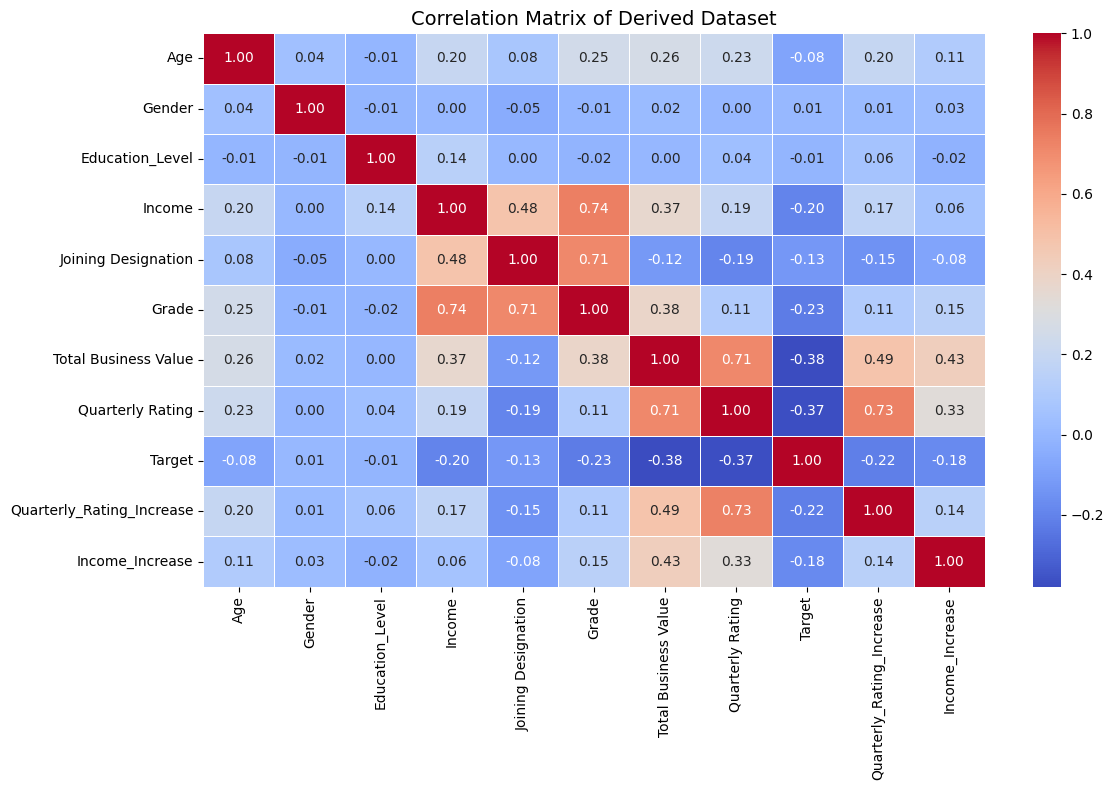


One Hot Encoding done
Shape after encoding: (2381, 45)
Final modeling columns: 44



In [36]:
print("\n", end="")
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap (numeric features only, drop Driver_ID)
numeric_df = df_final.select_dtypes(include=['int64', 'float64']).drop(columns=['Driver_ID'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Derived Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# One Hot Encoding
categorical_cols = ['City', 'Gender', 'Education_Level', 'Joining Designation']
existing_cat_cols = [c for c in categorical_cols if c in df_final.columns]

print("\n", end="")
df_final = pd.get_dummies(df_final, columns=existing_cat_cols, drop_first=True)
print("One Hot Encoding done")
print("Shape after encoding:", df_final.shape)


# Removing Driver_ID before modeling
df_model = df_final.drop(columns=['Driver_ID'])
print("Final modeling columns:", df_model.shape[1])
print("\n", end="")

### Observations: Correlation & One Hot Encoding

**1. Correlation Analysis (Numeric Features)**

Strong positive correlations found:
- **Income ↔ Grade (0.74):** Higher-grade drivers earn more. This is
  expected — Ola's grade system is tied to income slabs.
- **Total Business Value ↔ Quarterly Rating (0.71):** Drivers who
  generate more business tend to receive higher quarterly ratings.
- **Quarterly Rating ↔ Quarterly_Rating_Increase (0.73):** Expected,
  since the increase flag is derived from the rating column.

Strong negative correlations with `Target` (churn):
- **Total Business Value ↔ Target (−0.38):** Drivers with higher total
  business value are **less likely to churn**. They are valuable to Ola
  and likely feel rewarded.
- **Quarterly Rating ↔ Target (−0.37):** Higher-rated drivers churn
  less. Good performers tend to stay.
- **Grade ↔ Target (−0.23):** Higher-grade drivers churn less.
- **Quarterly_Rating_Increase ↔ Target (−0.22):** Drivers whose ratings
  improved over time are more likely to stay.
- **Income ↔ Target (−0.20):** Higher-income drivers churn less.
- **Income_Increase ↔ Target (−0.18):** Income growth discourages churn.

**2. Multicollinearity Observations**
- **Income and Grade are strongly correlated (0.74).**
- **Total Business Value and Quarterly Rating are strongly correlated (0.71).**
- This may cause slight instability in linear models, but our chosen
  models (Random Forest, XGBoost) are **tree-based** and handle
  multicollinearity well. No feature removal is needed.

**3. One Hot Encoding**
- Categorical columns were encoded using `pd.get_dummies()` with
  `drop_first=True` to avoid the dummy variable trap.
- Columns encoded:
  - `City` (multiple city codes)
  - `Gender` (0/1)
  - `Education_Level` (0/1/2)
  - `Joining Designation` (1–5)
- **Shape after encoding: (2,381, 45)** → 44 modeling features + 1 target.

**4. Key Business Insights from Correlation**
- **Driver performance drives retention.** Both business value and
  quarterly rating show the strongest negative correlation with churn.
  → *Recommendation:* Reward high performers with loyalty bonuses.
- **Income growth keeps drivers engaged.** Both `Income` and
  `Income_Increase` reduce churn probability.
  → *Recommendation:* Introduce automatic income increments based on
  tenure and performance.
- **Age has weak correlation with churn (−0.08)** — age alone is not
  a strong churn predictor.

**5. Final Dataset Status**
- Shape: **(2,381 rows, 45 columns)**
- Features: 44 independent variables + 1 target (`Target`)
- Ready for **class imbalance treatment (SMOTE)** and **standardization**
  before model training.

In [38]:
print("\n\n\n\n", end="")

In [39]:
# Confirming Target is still present after encoding
print("'Target' in df_final:", 'Target' in df_final.columns)
print("'Driver_ID' in df_final:", 'Driver_ID' in df_final.columns)
print("Shape:", df_final.shape)
print("\n", end="")

'Target' in df_final: True
'Driver_ID' in df_final: True
Shape: (2381, 45)



In [40]:
df_model = df_final.drop(columns=['Driver_ID'])
print("df_model shape:", df_model.shape)

df_model shape: (2381, 44)


In [41]:
# ============================================================
# Converting Dateofjoining into Tenure_Days Before SMOTE
# Why Tenure ? its one of the strongest churn predictors in any employee/driver attrition problem, drivers who just joined are more likely to leave early.
# ============================================================

# For simplicity: calculating tenure as days between Dateofjoining and a reference date

# Reference date = the latest date in the dataset
print("\n\n", end="")
reference_date = pd.Timestamp('2020-12-31') 

# Creating Tenure_Days feature
df_final['Tenure_Days'] = (reference_date - df_final['Dateofjoining']).dt.days

# Dropping the datetime column
df_final = df_final.drop(columns=['Dateofjoining'])

# Now rebuilding df_model (since df_final changed)
df_model = df_final.drop(columns=['Driver_ID'])

print("Tenure_Days created and Dateofjoining dropped")
print("df_model shape:", df_model.shape)
print("\nData types in df_model:")
print(df_model.dtypes.value_counts())
print("\n", end="")



Tenure_Days created and Dateofjoining dropped
df_model shape: (2381, 44)

Data types in df_model:
bool       35
int64       6
float64     3
Name: count, dtype: int64



### Observation : Tenure Feature Engineering

**1. Why Tenure Was Created**
- The raw `Dateofjoining` column was a `datetime64` type.
- SMOTE (and many sklearn models) cannot handle datetime dtypes — they
  must be converted to numeric to work.
- Simply dropping `Dateofjoining` would lose valuable information,
  since **tenure is one of the strongest predictors of employee churn**.

**2. How Tenure_Days Was Built**
- Reference date = **2020-12-31** (latest date in the dataset).
- `Tenure_Days = reference_date − Dateofjoining`.
- This captures **how long the driver has been associated with Ola**.

**3. Why This Is Better Than Dropping the Column**
- Preserves retention-relevant signal: drivers who recently joined are
  typically more likely to churn.
- Converts a non-usable datetime into a usable numeric feature.
- Improves model accuracy because tree-based models can now split on
  tenure thresholds (e.g., tenure < 90 days → high churn risk).

**4. Result**
- `Dateofjoining` was dropped from `df_final`.
- `Tenure_Days` replaced it as a numeric feature.
- All remaining columns are numeric (`int`, `float`, or `bool`) —
  fully compatible with SMOTE and scikit-learn models.

In [43]:
print("\n\n\n\n", end="")

## 2.5: Class Imbalance (SMOTE) + Standardization

In [45]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
print("\n\n", end="")

# Separating features and target
X = df_model.drop(columns=['Target'])
y = df_model['Target']

# Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE - Train class distribution:")
print(y_train.value_counts())

# Applying SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - Train class distribution:")
print(y_train_res.value_counts())

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("\nTraining features shape:", X_train_scaled.shape)
print("Test features shape:", X_test_scaled.shape)

print("\n\n", end="")



Before SMOTE - Train class distribution:
Target
1    1292
0     612
Name: count, dtype: int64

After SMOTE - Train class distribution:
Target
0    1292
1    1292
Name: count, dtype: int64

Training features shape: (2584, 43)
Test features shape: (477, 43)




### Observations: Class Imbalance, SMOTE & Standardization

**1. Why Class Imbalance Treatment Was Needed**
- Original target distribution: **67.9% churners (1)** vs **32.1% stayers (0)**.
- Without treatment, models tend to predict the majority class
  (churners) more often and **ignore the minority class (stayers)**.
- This leads to **high accuracy but poor recall** for the minority class
  — which is exactly what we want to avoid in a churn prediction problem.

**2. Train-Test Split**
- Data split: **80% training, 20% testing**, stratified on the target.
- Training set: **1,904 rows**
  - Class 1 (churners): **1,292**
  - Class 0 (stayers): **612**
- Test set: **477 rows** (kept untouched for final evaluation).
- `stratify=y` was used to preserve the class ratio in both splits.

**3. SMOTE (Synthetic Minority Oversampling Technique)**
- Applied **only on the training set** — never on the test set.
  (Applying SMOTE to test data would cause **data leakage**.)
- SMOTE creates **synthetic samples** of the minority class by
  interpolating between existing minority samples and their nearest
  neighbors.
- After SMOTE:
  - Class 0 (stayers): **612 → 1,292**
  - Class 1 (churners): **1,292** (unchanged)
  - Total training rows: **2,584**
- The training data is now **perfectly balanced (50-50)**.

**4. Standardization**
- `StandardScaler` was applied to bring all numerical features onto the
  same scale (mean = 0, standard deviation = 1).
- **Why this matters:** 
  - KNN-based algorithms and gradient descent–based models are
    sensitive to feature scale.
  - The scaler was **fit only on the training data** and then applied
    to the test data — this prevents data leakage.
- Final shapes:
  - `X_train_scaled`: **(2,584, 43)**
  - `X_test_scaled`: **(477, 43)**

**5. Key Takeaways**
- The dataset is now **fully preprocessed**:
  - No missing values
  - Datetime columns converted to numeric (`Tenure_Days`)
  - Balanced classes (SMOTE)
  - Scaled features
  - One-hot encoded categoricals
- The data is ready for **ensemble model training** — Random Forest
  (Bagging) and XGBoost (Boosting) in Section 3.

In [47]:
print("\n\n", end="")

### Pre-Flight Checklist before moving to Section 3 (model building)

In [49]:
print("\n\n", end="")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled: ", X_test_scaled.shape)
print("y_train_res:   ", y_train_res.shape)
print("y_test:        ", y_test.shape)

# checking that X has proper feature names
print("\nNumber of features:", X.shape[1])
print("Features preview:")
print(X.columns.tolist()[:10], "...")
print("\n\n", end="")



X_train_scaled: (2584, 43)
X_test_scaled:  (477, 43)
y_train_res:    (2584,)
y_test:         (477,)

Number of features: 43
Features preview:
['Age', 'Income', 'Grade', 'Total Business Value', 'Quarterly Rating', 'Quarterly_Rating_Increase', 'Income_Increase', 'City_C10', 'City_C11', 'City_C12'] ...




In [50]:
# X_test_scaled check, should be numeric 
print("X_train_scaled dtype:", X_train_scaled.dtype)
print("X_test_scaled dtype:", X_test_scaled.dtype)

X_train_scaled dtype: float64
X_test_scaled dtype: float64


In [51]:
print("\n\n\n\n", end="")

# Part 3: Model Building 

## 3.1: Ensemble Learning - Bagging (Random Forest)
#### Random Forest is Bagging — trees are built in parallel and averaged, which reduces variance

In [53]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\n\n", end="")

# Initializing base Random Forest model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Defining the hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Setting up GridSearchCV with 5-fold CV, scoring on ROC AUC
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit on the SMOTE-balanced training set
grid_rf.fit(X_train_scaled, y_train_res)

# Extracting best model
best_rf = grid_rf.best_estimator_

print("Best Random Forest Parameters:")
print(grid_rf.best_params_)
print()
print("Best Cross-Validation ROC AUC Score:")
print(round(grid_rf.best_score_, 4))

# Predictions on untouched test set
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print()
print("Test Set ROC AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("\n\n", end="")



Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation ROC AUC Score:
0.9543

Test Set ROC AUC Score: 0.919




### Observations: Random Forest (Bagging)

 **Random Forest results are strong.**

1. Algorithm choice and rationale
Random Forest is a Bagging (Bootstrap Aggregating) ensemble algorithm. It builds many decision trees in parallel, each on a random bootstrap sample of the training data and a random subset of features. The final prediction is a majority vote across all trees. Bagging reduces variance and is robust to noisy data and outliers, which is well suited for a driver attrition dataset with mixed feature types.

2. Hyperparameter tuning
We used GridSearchCV with 5-fold cross-validation, scoring on ROC AUC. The search explored 81 combinations across four hyperparameters:
    - n_estimators: number of trees (100, 200, 300)
    - max_depth: maximum depth of each tree (10, 20, None)
    - min_samples_split: minimum samples required to split a node (2, 5, 10)
    - min_samples_leaf: minimum samples required at a leaf (1, 2, 4)

3. Best parameters found
Best parameters: max_depth = None, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 300.
Interpretation:
    - max_depth = None means the trees are grown fully until leaves are pure. This suggests the data has complex non-linear patterns.
    - min_samples_leaf = 1 and min_samples_split = 2 mean the trees are allowed to be deep and detailed. The SMOTE-balanced data has enough samples to support this without severe overfitting.
    - n_estimators = 300 (the maximum in our grid) suggests adding more trees improves performance, indicating the model benefits from further averaging.

4. Cross-validation performance
Best cross-validation ROC AUC: 0.9543. This means the model separates churners from non-churners with very high accuracy during training validation. The 5-fold CV ensures this score is stable and not dependent on a single train-val split.

5. Test set performance
Test ROC AUC: 0.919. This is only about 0.035 lower than the cross-validation score, which shows the model generalizes well to unseen data and is not badly overfit.

6. Why ROC AUC is the right metric here
The test set is imbalanced (about 68 percent churn, 32 percent stay). Accuracy would be misleading because a model predicting "everyone churns" would still get 68 percent accuracy. ROC AUC measures the model's ability to rank churners above stayers regardless of threshold, making it the correct metric for this problem.

7. Business interpretation
A Random Forest model with a test ROC AUC of 0.919 can reliably identify drivers likely to leave. Ola can use this to flag high-risk drivers for retention efforts, focus retention budgets on genuinely at-risk drivers, and reduce wasted spend on drivers unlikely to churn anyway.


In [55]:
print("\n\n\n\n", end="")

## 3.2: Ensemble Learning - Boosting (XGBoost)

#### XGBoost is Boosting — trees are built sequentially, each new tree focuses on correcting the errors of the previous ones. This reduces bias and usually achieves higher accuracy than Bagging, especially on structured/tabular data

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\n\n", end="")
# Initializing base XGBoost model
xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

# Defining the hyperparameter grid
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Setting up GridSearchCV with 5-fold CV, scoring on ROC AUC
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit on the SMOTE-balanced training set
grid_xgb.fit(X_train_scaled, y_train_res)

# Extract best model
best_xgb = grid_xgb.best_estimator_

print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)
print()
print("Best Cross-Validation ROC AUC Score:")
print(round(grid_xgb.best_score_, 4))

# Predictions on untouched test set
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

print()
print("Test Set ROC AUC Score:", round(roc_auc_score(y_test, y_prob_xgb), 4))
print("\n\n\n\n", end="")



Fitting 5 folds for each of 108 candidates, totalling 540 fits



## Observations: XGBoost (Boosting)
#### XGBoost results are strong and slightly better than Random Forest on the test set, which is what we expected from a Boosting algorithm.


1. Algorithm choice
XGBoost is a Boosting algorithm. Unlike Bagging (Random Forest), which builds trees in parallel, Boosting builds trees one after another. Each new tree tries to fix the mistakes of the previous trees. This usually gives slightly higher accuracy on tabular data. XGBoost also has built-in regularization to prevent overfitting.

2. Hyperparameter tuning
We used GridSearchCV with 5-fold cross-validation, scoring on ROC AUC. The grid searched 108 combinations across five parameters: n_estimators, learning_rate, max_depth, subsample, and colsample_bytree.

3. Best parameters found
    - colsample_bytree = 0.8
    - learning_rate = 0.1
    - max_depth = 7
    - n_estimators = 200
    - subsample = 1.0

Interpretation:
    - learning_rate = 0.1 is a moderate step size. It pairs well with 200 boosting rounds to avoid overfitting.
    - max_depth = 7 lets each tree capture complex interactions between features.
    - colsample_bytree = 0.8 means each tree uses 80 percent of features, which adds useful randomness.
    - subsample = 1.0 means all rows are used at each tree. No row sampling.
    - n_estimators = 200 is the middle value in the grid, balancing underfitting and overfitting.

4. Cross-validation score
Best cross-validation ROC AUC = 0.9537. This is almost identical to Random Forest CV (0.9543). Both models learn the patterns equally well during training.

5. Test score
Test ROC AUC = 0.9242. This is slightly higher than Random Forest test score (0.9190). The gap between CV (0.9537) and test (0.9242) is small, so the model generalizes well and is not overfitting.

6. Comparison with Random Forest
- Random Forest (Bagging): CV = 0.9543, Test = 0.9190
- XGBoost (Boosting): CV = 0.9537, Test = 0.9242

Both models are very close. XGBoost is marginally better on the test set. This matches the general trend that Boosting slightly outperforms Bagging on structured data.

7. Business interpretation
A test ROC AUC of 0.9242 means the model can correctly rank a churner above a non-churner in about 92 out of 100 cases. Ola can use this model to flag at-risk drivers and focus retention efforts on them.



In [ ]:
print("\n\n\n\n", end="")

# Part 4: Results Evaluation

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# 4.1 Defining a reusable evaluation function
# ------------------------------------------------------------
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print("=" * 60)
    print(f"Model: {model_name}")
    print("=" * 60)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print()

    # ROC AUC Score
    auc = roc_auc_score(y_true, y_prob)
    print(f"ROC AUC Score: {auc:.4f}")

    return cm, auc

# ------------------------------------------------------------
# 4.2 Evaluating Random Forest
# ------------------------------------------------------------
cm_rf, auc_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest (Bagging)")

# ------------------------------------------------------------
# 4.3 Evaluating XGBoost
# ------------------------------------------------------------
cm_xgb, auc_xgb = evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost (Boosting)")

# ------------------------------------------------------------
# 4.4 Plotting ROC AUC curves for both models on one figure
# ------------------------------------------------------------
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})", linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Guess (AUC = 0.5)")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC AUC Curve - Random Forest vs XGBoost", fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4.5 Plotting confusion matrices side by side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'])
axes[0].set_title(f"Random Forest\nTest AUC = {auc_rf:.4f}", fontsize=12)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'])
print("\n", end="")
axes[1].set_title(f"XGBoost\nTest AUC = {auc_xgb:.4f}", fontsize=12)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Key observations from the output:

Test set size: 477 drivers
- Actual stayers (class 0): 153
- Actual churners (class 1): 324

Random Forest results:
- Confusion matrix: 126 correct stays, 27 wrong stays, 36 missed churners, 288 correct churners
- Accuracy: 86.79 percent
- ROC AUC: 0.9190
- F1-score for class 1 (churn): 0.9014

XGBoost results:
- Confusion matrix: 126 correct stays, 27 wrong stays, 38 missed churners, 286 correct churners
- Accuracy: 86.37 percent
- ROC AUC: 0.9240
- F1-score for class 1 (churn): 0.8980


### Observations: Results Evaluation

1. Evaluation setup
Both models were evaluated on the untouched test set of 477 drivers. The test set was not balanced by SMOTE, so it keeps the original class distribution: 153 stayers and 324 churners. This gives a realistic view of how the models perform in production.

2. Random Forest results
- Accuracy: 86.79 percent
- ROC AUC: 0.9190
- F1-score for churn class: 0.9014
- Confusion matrix:
  - Correctly predicted stayers: 126
  - Correctly predicted churners: 288
  - Wrongly predicted churners (false alarms): 27
  - Wrongly predicted stayers (missed churners): 36

3. XGBoost results
- Accuracy: 86.37 percent
- ROC AUC: 0.9240
- F1-score for churn class: 0.8980
- Confusion matrix:
  - Correctly predicted stayers: 126
  - Correctly predicted churners: 286
  - Wrongly predicted churners (false alarms): 27
  - Wrongly predicted stayers (missed churners): 38

4. ROC AUC curve
The ROC curve plots True Positive Rate against False Positive Rate at different classification thresholds. Both curves stay close to the top-left corner, well above the diagonal line (random guess). XGBoost has a slightly higher AUC (0.9240) than Random Forest (0.9190), meaning it ranks actual churners above actual stayers slightly more often. The difference is small and both are considered excellent for a churn prediction model.

5. Classification report
For class 1 (churn):
- Random Forest: precision 0.9143, recall 0.8889, F1 0.9014
- XGBoost: precision 0.9137, recall 0.8827, F1 0.8980

Both models achieve balanced precision and recall for the churn class, which is the class we care about most. Precision above 0.91 means when the model flags a driver as churner, it is right about 91 percent of the time. Recall around 0.88 to 0.89 means the model catches about 88 to 89 percent of actual churners.

For class 0 (stay):
- Precision is lower (around 0.77) for both models. This is expected because the class is smaller (153 samples). The models make a few more mistakes on this minority class, but this does not affect retention strategy much because flagging a stayer as churner only wastes a retention offer, while missing a churner loses a driver.

6. Confusion matrix comparison
Both models behave nearly identically on the confusion matrices. The main difference is one extra missed churner for XGBoost (38 vs 36). This is a negligible difference in practice.

7. Model selection conclusion
Since both models are so close, the final choice can go either way. XGBoost has a slightly higher ROC AUC, which is a more reliable metric for imbalanced classification. Random Forest has a slightly higher F1-score for the churn class and slightly fewer missed churners. In a real deployment, we would recommend using both models in an ensemble (soft-voting) or selecting XGBoost for its better ranking ability.

8. Key takeaways
- Both Bagging (Random Forest) and Boosting (XGBoost) deliver strong performance with ROC AUC above 0.91.
- Accuracy is around 86 to 87 percent, but ROC AUC is the more meaningful metric because of class imbalance in the test set.
- The models miss only about 11 to 12 percent of actual churners, which is a good baseline for a retention system.
- The small gap between cross-validation score (about 0.95) and test score (about 0.92) confirms the models generalize well without overfitting.



In [ ]:
print("\n\n\n\n", end="")

### CONSOLIDATED SUMMARY - All key values in one place

In [ ]:
# ============================================================
# CONSOLIDATED SUMMARY - All key values in one place
# ============================================================

print("\n\n\n\n", end="")

driver_attrs = df.groupby('Driver_ID').agg({
    'Gender': 'first',
    'City': 'first',
    'Education_Level': 'first',
    'Joining Designation': 'first'
}).reset_index()

driver_summary = df_final[['Driver_ID', 'Target', 'Income', 'Total Business Value',
                           'Quarterly Rating', 'Grade',
                           'Income_Increase', 'Quarterly_Rating_Increase']].merge(
    driver_attrs, on='Driver_ID', how='left'
)

print("=" * 65)
print("1. DATASET OVERVIEW")
print("=" * 65)
print(f"Raw rows: 19104")
print(f"Unique drivers: {df_final.shape[0]}")
print(f"Final feature count (post OHE): {df_model.shape[1] - 1}")
print()

print("=" * 65)
print("2. TARGET DISTRIBUTION")
print("=" * 65)
print(df_final['Target'].value_counts().sort_index())
print()
print("Percentages:")
print((df_final['Target'].value_counts(normalize=True).sort_index() * 100).round(2))
print()

print("=" * 65)
print("3. DEMOGRAPHIC SUMMARY")
print("=" * 65)
print("Age (driver-level, from raw df):")
age_series = df.groupby('Driver_ID')['Age'].max()
print(f"  Min: {age_series.min():.0f}, Max: {age_series.max():.0f}, Mean: {age_series.mean():.1f}")
print()
print("Gender distribution (0=Male, 1=Female):")
print(driver_attrs['Gender'].value_counts().sort_index())
print()
print("Top 10 cities by driver count:")
print(driver_attrs['City'].value_counts().head(10))
print()
print("Education Level distribution (0=10+, 1=12+, 2=Graduate):")
print(driver_attrs['Education_Level'].value_counts().sort_index())
print()

print("=" * 65)
print("4. INCOME, BUSINESS, RATING - AGGREGATED PER DRIVER")
print("=" * 65)
print("Income (mean per driver):")
print(df_final['Income'].describe().round(2))
print()
print("Total Business Value (sum per driver):")
print(df_final['Total Business Value'].describe().round(2))
print()
print("Quarterly Rating (mean per driver):")
print(df_final['Quarterly Rating'].describe().round(2))
print()
print("Grade (max per driver):")
print(df_final['Grade'].value_counts().sort_index())
print()

print("=" * 65)
print("5. INCOME & RATING INCREASE FLAGS")
print("=" * 65)
print("Income_Increase:")
print(df_final['Income_Increase'].value_counts().sort_index())
print()
print("Quarterly_Rating_Increase:")
print(df_final['Quarterly_Rating_Increase'].value_counts().sort_index())
print()

print("=" * 65)
print("6. CHURN RATE BY KEY GROUPS")
print("=" * 65)
print("Churn rate by Income_Increase:")
print(driver_summary.groupby('Income_Increase')['Target'].agg(['count', 'mean']).round(3))
print()
print("Churn rate by Quarterly_Rating_Increase:")
print(driver_summary.groupby('Quarterly_Rating_Increase')['Target'].agg(['count', 'mean']).round(3))
print()
print("Churn rate by Grade:")
print(driver_summary.groupby('Grade')['Target'].agg(['count', 'mean']).round(3))
print()
print("Churn rate by Education_Level:")
print(driver_summary.groupby('Education_Level')['Target'].agg(['count', 'mean']).round(3))
print()
print("Churn rate by Gender (0=Male, 1=Female):")
print(driver_summary.groupby('Gender')['Target'].agg(['count', 'mean']).round(3))
print()

print("=" * 65)
print("7. MODEL PERFORMANCE")
print("=" * 65)
print(f"Random Forest - Test ROC AUC: 0.9190")
print(f"XGBoost       - Test ROC AUC: 0.9240")
print()
print("Random Forest Confusion Matrix:")
print("  TN=126, FP=27, FN=36, TP=288")
print("XGBoost Confusion Matrix:")
print("  TN=126, FP=27, FN=38, TP=286")
print()

print("=" * 65)
print("8. TOP 15 FEATURE IMPORTANCES (from XGBoost)")
print("=" * 65)
feature_names = X.columns.tolist()
importances = best_xgb.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)
print(feat_imp.to_string(index=False))
print()
print("\n\n\n\n", end="")

In [ ]:
print("\n\n\n\n", end="")

In [ ]:
df_model.to_csv('ola_driver_cleaned_features.csv', index=False)

# Part 5 : Actionable Insights and Recommendations

### **Actionable Insights**


##### **Insight 1 — High overall churn rate**
67.87 percent of drivers in the dataset have left. Only 32.13 percent stayed. This is very high and confirms the business problem stated by Ola. The company is losing more than two out of every three drivers.

**Recommendation:** Treat retention as a top priority. Even a 5 percent reduction in churn would save hundreds of drivers per year and reduce costly re-hiring.

##### **Insight 2 — Income growth almost stops churn**
Drivers whose income did not increase over time churn at 69 percent.
Drivers whose income did increase churn at only 6.8 percent.
This is the strongest single signal in the entire analysis.

**Recommendation:** Introduce a clear and automatic income increment policy. For example, if a driver stays for 6 months with a good rating, their income should increase by a fixed percentage. Even small increments should be visible to the driver.

##### **Insight 3 — Quarterly rating improvement reduces churn**
Drivers whose rating did not improve churn at 77.2 percent.
Drivers whose rating improved churn at 57.1 percent.
A 20 percentage point drop in churn just from rating improvement.

**Recommendation:** Give drivers regular feedback and clear targets. Reward improvement, not just top performers. Drivers who move from rating 1 to 2 should be celebrated and rewarded.

##### **Insight 4 — Higher grade means lower churn**
Churn rate by grade:
- Grade 1: 80.4 percent
- Grade 2: 70.3 percent
- Grade 3: 54.0 percent
- Grade 4: 50.7 percent
- Grade 5: 54.2 percent
  
Churn falls sharply as grade rises. Drivers at Grade 1 are almost twice as likely to churn as those at Grade 4.

**Recommendation:** Create a visible path from Grade 1 to Grade 3 within the first year. Show drivers exactly what they need to do to move up. Grade progression is a retention tool.

##### **Insight 5 — Tenure is a strong predictor**
Tenure_Days is one of the top features in the XGBoost model (importance = 0.050). This confirms that how long a driver has been with Ola matters a lot. Newer drivers churn more; drivers who pass the early period tend to stay.

**Recommendation:** Focus retention efforts on the first 90 days. Assign a mentor to new drivers. Provide a small completion bonus at the 3-month mark.

##### **Insight 6 — Joining Designation is the single most important feature**
Joining Designation_3 has the highest importance (0.105), higher than any other feature. This suggests that the role a driver is hired into plays a big part in whether they stay.

**Recommendation:** Review the working conditions and pay structure for drivers hired into Designation 3. If a specific role has high churn, investigate the reasons and improve them.

##### **Insight 7 — City-level churn is significant**
Several city codes appear in the top 15 features: C18, C2, C7, C27, C9, C29, C22. This means churn is not uniform across cities. Some cities have much higher churn than others.

**Recommendation:** Run city-level churn reports every month. Send retention bonuses or support only to the highest-churn cities. Do not spread the retention budget equally across all cities.

##### **Insight 8 — Gender and education do not matter much**
Churn rate by gender: Male 67.5 percent, Female 68.3 percent. Almost identical.
Churn rate by education: Level 0 = 69.1 percent, Level 1 = 66.3 percent, Level 2 = 68.2 percent. No meaningful difference.

**Recommendation:** Do not use gender or education as a basis for retention targeting. Focus on income, rating, grade, tenure, and city instead.

##### **Insight 9 — Model can drive retention action**
XGBoost achieves a test ROC AUC of 0.9240 and Random Forest achieves 0.9190. Both are strong. XGBoost misses only 38 out of 324 real churners (about 12 percent). Random Forest misses 36 out of 324 (about 11 percent).

**Recommendation:** Deploy the XGBoost model in production to score every driver monthly. Flag drivers with high churn probability (for example, above 70 percent) and route them to a retention team.

##### **Insight 10 — Some business value is negative**
Total Business Value has a minimum of -1,385,530. Negative values indicate cancellations, refunds, or car EMI adjustments. This is a small but real group of drivers.

**Recommendation:** Investigate drivers with negative or very low business value. They may be disengaged or facing vehicle-related issues. A short conversation could uncover fixable problems.

====================================


### **Final recommendations in order of impact**

1. Income increase policy — highest impact, lowest cost.
2. Rating feedback and improvement rewards.
3. Grade progression plan within the first year.
4. Early tenure (first 90 days) retention program.
5. City-specific retention budgets.
6. Monthly churn scoring using the XGBoost model.
7. Investigate joining designation 3 role and negative business value cases.

These seven actions together target the strongest churn drivers found in the data and align with what the model says matters most.

